# Yfinance IV vs Own Calculated IV

Compare the original yfinance implied-volatility calibration results with the rerun that uses Black-Scholes implied volatility calculated from option mid prices.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PARAMETER_COLUMNS = ["v0", "kappa", "theta", "sigma_v", "rho"]

## Settings

In [2]:
MARKET_PATH = Path("data/spy_options_clean_with_iv.csv")
OUTPUT_DIR = Path("outputs/iv_source_comparison")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Parent outputs are the original yfinance-IV calibration results.
YF_GP_DIR = Path("../outputs/gp_calibration")
YF_FFT_DIR = Path("../outputs/fft_calibration")

# Local outputs are the own-IV rerun results inside this folder.
OWN_GP_DIR = Path("outputs/gp_calibration")
OWN_FFT_DIR = Path("outputs/fft_calibration")

## Load Inputs

In [3]:
def load_summary(target_source: str, method: str, directory: Path) -> pd.Series:
    row = pd.read_csv(directory / "calibration_summary.csv").iloc[0].copy()
    row["target_source"] = target_source
    row["method"] = method
    return row


def load_predictions(target_source: str, method: str, directory: Path) -> pd.DataFrame:
    data = pd.read_csv(directory / "calibration_predictions.csv")
    data["target_source"] = target_source
    data["method"] = method
    return data


summaries = pd.DataFrame([
    load_summary("yfinance IV", "GP", YF_GP_DIR),
    load_summary("yfinance IV", "FFT", YF_FFT_DIR),
    load_summary("own IV", "GP", OWN_GP_DIR),
    load_summary("own IV", "FFT", OWN_FFT_DIR),
])

predictions = pd.concat([
    load_predictions("yfinance IV", "GP", YF_GP_DIR),
    load_predictions("yfinance IV", "FFT", YF_FFT_DIR),
    load_predictions("own IV", "GP", OWN_GP_DIR),
    load_predictions("own IV", "FFT", OWN_FFT_DIR),
], ignore_index=True)

market = pd.read_csv(MARKET_PATH)
valid_market = market.dropna(subset=["impliedVolatility", "iv_own"]).copy()

summaries[["target_source", "method", "contracts", "rmse", "mae", "wall_clock_seconds"]]

,target_source,method,contracts,rmse,mae,wall_clock_seconds
0,yfinance IV,GP,973,0.149996,0.091150,3.883935
0,yfinance IV,FFT,973,0.134680,0.089626,3.495879
0,own IV,GP,899,0.102467,0.054804,12.270437
0,own IV,FFT,899,0.079893,0.045254,3.474511


## 1 Target IV Comparison

In [4]:
# Compare yfinance and own IV only where the own root solve succeeded.
iv_diff = valid_market["iv_own"] - valid_market["impliedVolatility"]

target_stats = pd.DataFrame({
    "metric": [
        "total rows",
        "valid own-IV rows",
        "own-IV missing rows",
        "correlation",
        "mean own minus yfinance",
        "mean absolute difference",
        "median absolute difference",
    ],
    "value": [
        len(market),
        len(valid_market),
        int(market["iv_own"].isna().sum()),
        valid_market["impliedVolatility"].corr(valid_market["iv_own"]),
        iv_diff.mean(),
        iv_diff.abs().mean(),
        iv_diff.abs().median(),
    ],
})

target_stats.to_csv(OUTPUT_DIR / "target_iv_stats.csv", index=False)
target_stats

,metric,value
0,total rows,973.000000
1,valid own-IV rows,899.000000
2,own-IV missing rows,74.000000
3,correlation,0.963144
4,mean own minus yfinance,-0.014269
5,mean absolute difference,0.033068
6,median absolute difference,0.015463


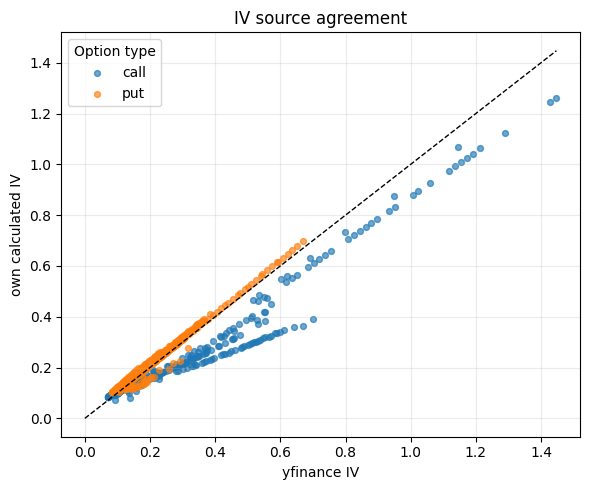

Saved plot to outputs/iv_source_comparison/target_iv_scatter.png


In [5]:
# A 45-degree scatter shows where own IV agrees with yfinance IV.
fig, ax = plt.subplots(figsize=(6, 5))
for option_type, group in valid_market.groupby("type"):
    ax.scatter(
        group["impliedVolatility"],
        group["iv_own"],
        s=18,
        alpha=0.65,
        label=option_type,
    )

limit = float(np.nanmax(valid_market[["impliedVolatility", "iv_own"]].to_numpy()))
ax.plot([0, limit], [0, limit], color="black", linewidth=1, linestyle="--")
ax.set_xlabel("yfinance IV")
ax.set_ylabel("own calculated IV")
ax.set_title("IV source agreement")
ax.grid(True, alpha=0.25)
ax.legend(title="Option type")
fig.tight_layout()

target_scatter_path = OUTPUT_DIR / "target_iv_scatter.png"
fig.savefig(target_scatter_path, dpi=180)
plt.show()

print(f"Saved plot to {target_scatter_path}")

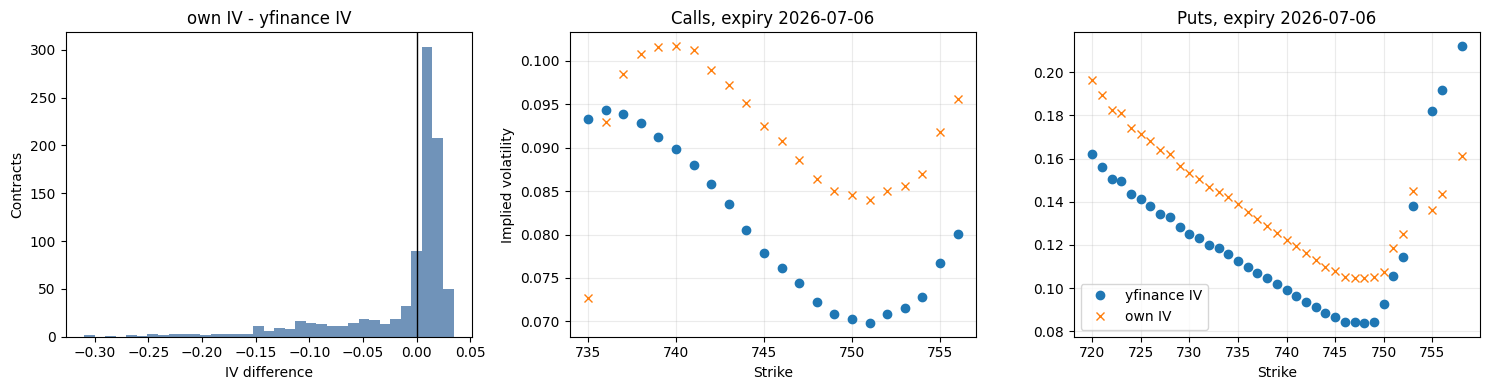

Saved plot to outputs/iv_source_comparison/target_iv_differences.png


In [6]:
# Inspect the IV difference distribution and the first available smile.
first_expiry = valid_market["expiry"].sort_values().iloc[0]
smile_market = valid_market.loc[valid_market["expiry"] == first_expiry].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(iv_diff, bins=35, color="#4C78A8", alpha=0.8)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("own IV - yfinance IV")
axes[0].set_xlabel("IV difference")
axes[0].set_ylabel("Contracts")

for ax, option_type in zip(axes[1:], ["call", "put"]):
    subset = smile_market.loc[smile_market["type"] == option_type].sort_values("strike")
    ax.plot(subset["strike"], subset["impliedVolatility"], "o", label="yfinance IV")
    ax.plot(subset["strike"], subset["iv_own"], "x", label="own IV")
    ax.set_title(f"{option_type.title()}s, expiry {first_expiry}")
    ax.set_xlabel("Strike")
    ax.grid(True, alpha=0.25)

axes[1].set_ylabel("Implied volatility")
axes[2].legend(loc="best")
fig.tight_layout()

target_diff_path = OUTPUT_DIR / "target_iv_differences.png"
fig.savefig(target_diff_path, dpi=180)
plt.show()

print(f"Saved plot to {target_diff_path}")

## 2 Calibration Metric Comparison

In [7]:
metric_table = summaries[[
    "target_source",
    "method",
    "contracts",
    "total_calibration_error",
    "rmse",
    "mae",
    "wall_clock_seconds",
    "success",
]].copy()

metric_table.to_csv(OUTPUT_DIR / "calibration_metric_comparison.csv", index=False)
metric_table.sort_values(["method", "target_source"])

,target_source,method,contracts,total_calibration_error,rmse,mae,wall_clock_seconds,success
0,own IV,FFT,899,5.738206,0.079893,0.045254,3.474511,True
0,yfinance IV,FFT,973,17.649008,0.134680,0.089626,3.495879,True
0,own IV,GP,899,9.438989,0.102467,0.054804,12.270437,True
0,yfinance IV,GP,973,21.891259,0.149996,0.091150,3.883935,True


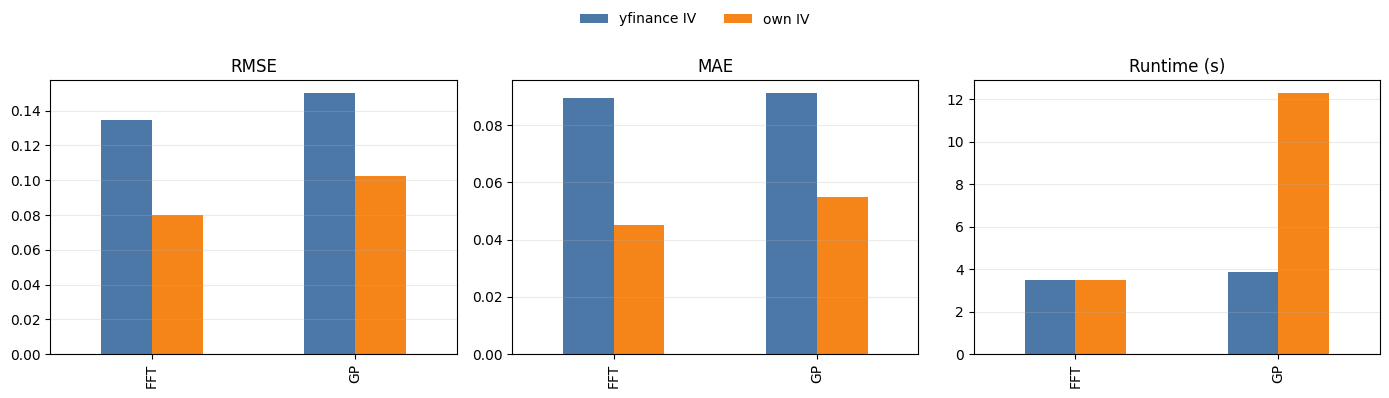

Saved plot to outputs/iv_source_comparison/calibration_metrics_by_iv_source.png


In [8]:
# Compare fit error and runtime by calibration method and IV source.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [("rmse", "RMSE"), ("mae", "MAE"), ("wall_clock_seconds", "Runtime (s)")]
colors = {"yfinance IV": "#4C78A8", "own IV": "#F58518"}

for ax, (column, title) in zip(axes, metrics):
    pivot = metric_table.pivot(index="method", columns="target_source", values=column)
    pivot[["yfinance IV", "own IV"]].plot(kind="bar", ax=ax, color=[colors["yfinance IV"], colors["own IV"]])
    ax.set_title(title)
    ax.set_xlabel("")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.tight_layout(rect=[0, 0, 1, 0.9])

metrics_plot_path = OUTPUT_DIR / "calibration_metrics_by_iv_source.png"
fig.savefig(metrics_plot_path, dpi=180)
plt.show()

print(f"Saved plot to {metrics_plot_path}")

## 3 Fitted Parameter Comparison

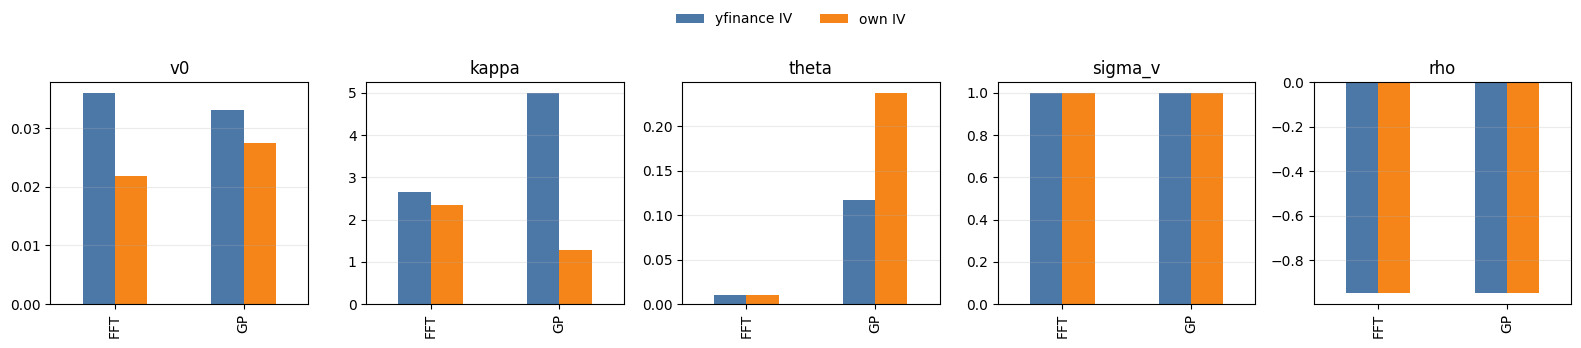

Saved plot to outputs/iv_source_comparison/parameters_by_iv_source.png


In [9]:
parameter_table = summaries.melt(
    id_vars=["target_source", "method"],
    value_vars=PARAMETER_COLUMNS,
    var_name="parameter",
    value_name="value",
)

parameter_table.to_csv(OUTPUT_DIR / "parameter_by_iv_source.csv", index=False)

fig, axes = plt.subplots(1, len(PARAMETER_COLUMNS), figsize=(16, 3.5))
for ax, parameter in zip(axes, PARAMETER_COLUMNS):
    subset = parameter_table.loc[parameter_table["parameter"] == parameter]
    pivot = subset.pivot(index="method", columns="target_source", values="value")
    pivot[["yfinance IV", "own IV"]].plot(kind="bar", ax=ax, color=["#4C78A8", "#F58518"])
    ax.set_title(parameter)
    ax.set_xlabel("")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.tight_layout(rect=[0, 0, 1, 0.88])

parameter_plot_path = OUTPUT_DIR / "parameters_by_iv_source.png"
fig.savefig(parameter_plot_path, dpi=180)
plt.show()

print(f"Saved plot to {parameter_plot_path}")

## 4 Fitted Smile Comparison

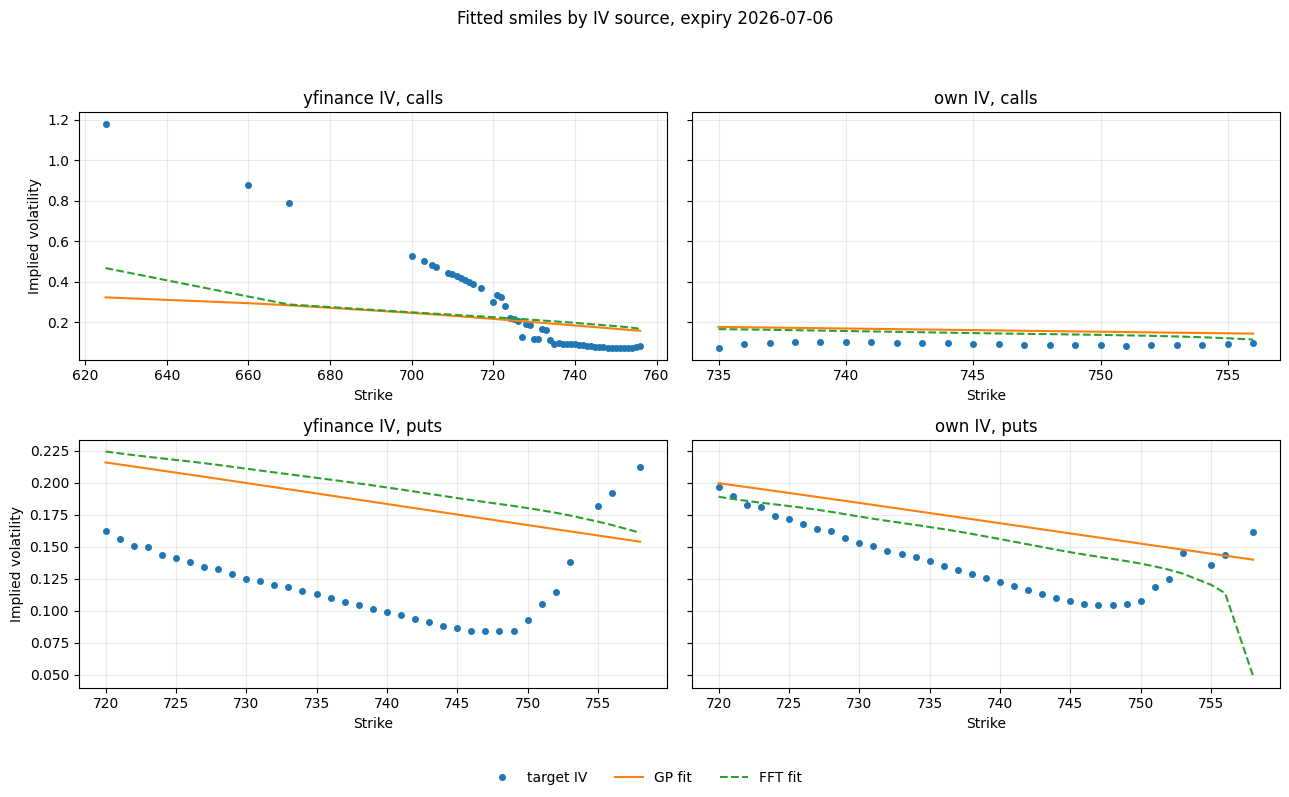

Saved plot to outputs/iv_source_comparison/fitted_smiles_by_iv_source.png


In [10]:
def prediction_column(method: str) -> str:
    return "gp_predicted_iv" if method == "GP" else "fft_predicted_iv"


def plot_smile(ax, target_source: str, option_type: str, expiry: str) -> None:
    gp = predictions.query("target_source == @target_source and method == 'GP'")
    fft = predictions.query("target_source == @target_source and method == 'FFT'")
    gp = gp.loc[(gp["expiry"] == expiry) & (gp["type"] == option_type)].sort_values("strike")
    fft = fft.loc[(fft["expiry"] == expiry) & (fft["type"] == option_type)].sort_values("strike")

    ax.plot(gp["strike"], gp["market_iv"], "o", label="target IV", markersize=4)
    ax.plot(gp["strike"], gp["gp_predicted_iv"], "-", label="GP fit", linewidth=1.5)
    ax.plot(fft["strike"], fft["fft_predicted_iv"], "--", label="FFT fit", linewidth=1.5)
    ax.set_title(f"{target_source}, {option_type}s")
    ax.set_xlabel("Strike")
    ax.grid(True, alpha=0.25)


common_expiries = sorted(set(predictions["expiry"]))
plot_expiry = common_expiries[0]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey="row")
for row, option_type in enumerate(["call", "put"]):
    for col, target_source in enumerate(["yfinance IV", "own IV"]):
        plot_smile(axes[row, col], target_source, option_type, plot_expiry)
        if col == 0:
            axes[row, col].set_ylabel("Implied volatility")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.suptitle(f"Fitted smiles by IV source, expiry {plot_expiry}", y=0.98)
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.tight_layout(rect=[0, 0.06, 1, 0.94])

smile_plot_path = OUTPUT_DIR / "fitted_smiles_by_iv_source.png"
fig.savefig(smile_plot_path, dpi=180)
plt.show()

print(f"Saved plot to {smile_plot_path}")

## Discussion

In [11]:
# Keep the conclusion data-driven and explicit about comparability limits.
own_rows = int(metric_table.loc[metric_table["target_source"] == "own IV", "contracts"].iloc[0])
yf_rows = int(metric_table.loc[metric_table["target_source"] == "yfinance IV", "contracts"].iloc[0])

rows = []
for method in ["GP", "FFT"]:
    method_rows = metric_table.loc[metric_table["method"] == method].set_index("target_source")
    rmse_change = method_rows.loc["own IV", "rmse"] - method_rows.loc["yfinance IV", "rmse"]
    mae_change = method_rows.loc["own IV", "mae"] - method_rows.loc["yfinance IV", "mae"]
    rows.append({"method": method, "rmse_change_own_minus_yfinance": rmse_change, "mae_change_own_minus_yfinance": mae_change})

change_table = pd.DataFrame(rows)
change_table.to_csv(OUTPUT_DIR / "metric_changes_own_minus_yfinance.csv", index=False)

print(f"The own-IV calibrations used {own_rows} contracts; the yfinance-IV calibrations used {yf_rows} contracts.")
print("Lower own-IV errors therefore show a cleaner fit to the own-IV target, but not a strict apples-to-apples proof of better market accuracy.")
print("Own IV is better for this project when transparency, reproducibility, and consistency with mid prices, r, and q matter most.")
print("Yfinance IV remains useful as an external benchmark, but it may embed different quote choices, rate assumptions, dividend assumptions, or data-cleaning rules.")

change_table

The own-IV calibrations used 899 contracts; the yfinance-IV calibrations used 973 contracts.
Lower own-IV errors therefore show a cleaner fit to the own-IV target, but not a strict apples-to-apples proof of better market accuracy.
Own IV is better for this project when transparency, reproducibility, and consistency with mid prices, r, and q matter most.
Yfinance IV remains useful as an external benchmark, but it may embed different quote choices, rate assumptions, dividend assumptions, or data-cleaning rules.


,method,rmse_change_own_minus_yfinance,mae_change_own_minus_yfinance
0,GP,-0.047529,-0.036345
1,FFT,-0.054787,-0.044372


### Takeaways

- Own IV is not automatically more correct than yfinance IV; it is more transparent because it is directly tied to the chosen mid price, risk-free rate, dividend yield, and Black-Scholes inversion method.
- Failed own-IV roots are informative. They flag quotes that cannot be reconciled with Black-Scholes inside the chosen volatility range, so the own-IV workflow applies an additional quality filter.
- The calibration-error comparison should be read as fit-to-target quality. If the own-IV target is cleaner and internally consistent, lower errors are meaningful for this pipeline, but they are not independent evidence that the true market volatility is lower-error.
- In this project, own IV is preferable for calibration experiments where reproducibility and control over assumptions matter; yfinance IV is preferable as a reference series for external comparison.